In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minimos_cuadrados import minimos_cuadrados
from minimos_cuadrado_vid import minimos_cuadrados_vid

In [110]:
# Cargar el dataframe con las variables que se van a utilizar
df = pd.read_csv(r"asthma_disease_data.csv")
pd.set_option('display.max_rows', None)
cols = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies" , "Diagnosis"
]
# Vuelve a cargar el dataframe con las variables seleccionadas
df = pd.read_csv("asthma_disease_data.csv", usecols=cols)
# Elimina las filas con valores nulos
df = df.dropna()
print(df)

      Age  Gender  Smoking  PhysicalActivity  DietQuality  PollutionExposure  \
0      63       0        0          0.894448     5.488696           7.388481   
1      26       1        0          5.897329     6.341014           1.969838   
2      57       0        0          6.739367     9.196237           1.460593   
3      40       1        0          1.404503     5.826532           0.581905   
4      61       0        0          4.604493     3.127048           0.980875   
5      21       0        0          0.470044     1.759118           1.711446   
6      45       1        1          9.371784     7.030507           7.664306   
7      26       0        1          8.344096     1.626484           6.939046   
8      49       1        0          2.690256     3.920034           3.180421   
9      45       1        0          2.895720     2.607700           1.711722   
10     27       0        0          3.900003     1.748193           1.546419   
11     62       1        0          6.63

In [111]:
# Muestra las dimensiones del dataframe
df.shape

(2392, 11)

In [112]:
# Muestra la información detallada del dataframe para verificar los tipos de datos y si existen valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2392 non-null   int64  
 1   Gender               2392 non-null   int64  
 2   Smoking              2392 non-null   int64  
 3   PhysicalActivity     2392 non-null   float64
 4   DietQuality          2392 non-null   float64
 5   PollutionExposure    2392 non-null   float64
 6   PollenExposure       2392 non-null   float64
 7   DustExposure         2392 non-null   float64
 8   FamilyHistoryAsthma  2392 non-null   int64  
 9   HistoryOfAllergies   2392 non-null   int64  
 10  Diagnosis            2392 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 205.7 KB


In [113]:
# Agrupa la proporcion de diagnóstico por edad
# Esto asume que 'Diagnosis' es una columna binaria donde 1 indica diagnóstico positivo y 0 negativo.
prevalencia_edad = df.groupby('Age')['Diagnosis'].mean()
x = df["Age"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados(x, y, 4))

La recta ajustada es: y = -0.0002x + 0.0584


In [114]:
# Agrupa la proporcion de diagnóstico por genero
prevalencia_genero = df.groupby('Gender')['Diagnosis'].mean()
x = df["Gender"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados(x, y, 4))

La recta ajustada es: y = 0.0014x + 0.0512


In [115]:
# Agrupa la proporcion de diagnóstico por consumo de tabaco
prevalencia_fumadores = df.groupby('Smoking')['Diagnosis'].mean()
x = df["Smoking"].astype(float).tolist()    
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados(x, y, 4))

La recta ajustada es: y = -0.0123x + 0.0536


In [116]:
# Agrupa la proporcion de diagnóstico por actividad física
prevalencia_act_fisica = df.groupby('PhysicalActivity')['Diagnosis'].mean()
x = df["PhysicalActivity"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados(x, y, 4))

La recta ajustada es: y = 0.0004x + 0.0499


In [117]:
# Agrupa la proporcion de diagnóstico por calidad de la dieta
prevalencia_calidad_dieta = df.groupby('DietQuality')['Diagnosis'].mean()
x = df["DietQuality"].astype(float).tolist()   
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados(x, y, 4))     

La recta ajustada es: y = -0.0002x + 0.053


In [118]:
# La agrupación con la proporción de diagnóstico con la contaminación ambiental (polución)
prevalencia_genero = df.groupby('PollutionExposure')['Diagnosis'].mean()
x = df["PollutionExposure"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados_vid(x, y, 4))

(0.0536, -0.0003)


In [119]:
# La agrupación con la proporción de diagnóstico con la exposición al polen.
prevalencia_genero = df.groupby('PollenExposure')['Diagnosis'].mean()
x = df["PollenExposure"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados_vid(x, y, 4))

(0.0459, 0.0012)


In [120]:
# La agrupación con la proporción de diagnóstico con la exposición al polvo.
prevalencia_genero = df.groupby('DustExposure')['Diagnosis'].mean()
x = df["DustExposure"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados_vid(x, y, 4))

(0.0619, -0.002)


In [121]:
# La agrupación con la proporción de diagnóstico con el historial familar con respecto al Asma.
prevalencia_genero = df.groupby('FamilyHistoryAsthma')['Diagnosis'].mean()
x = df["FamilyHistoryAsthma"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados_vid(x, y, 4))

(0.052, -0.0006)


In [122]:
# La agrupación con la proporción de diagnóstico con el historial de alergias del paciente.
prevalencia_genero = df.groupby('HistoryOfAllergies')['Diagnosis'].mean()
x = df["HistoryOfAllergies"].astype(float).tolist()
y = df["Diagnosis"].astype(float).tolist()
print(minimos_cuadrados_vid(x, y, 4))

(0.0522, -0.0009)


<Figure size 1000x600 with 0 Axes>

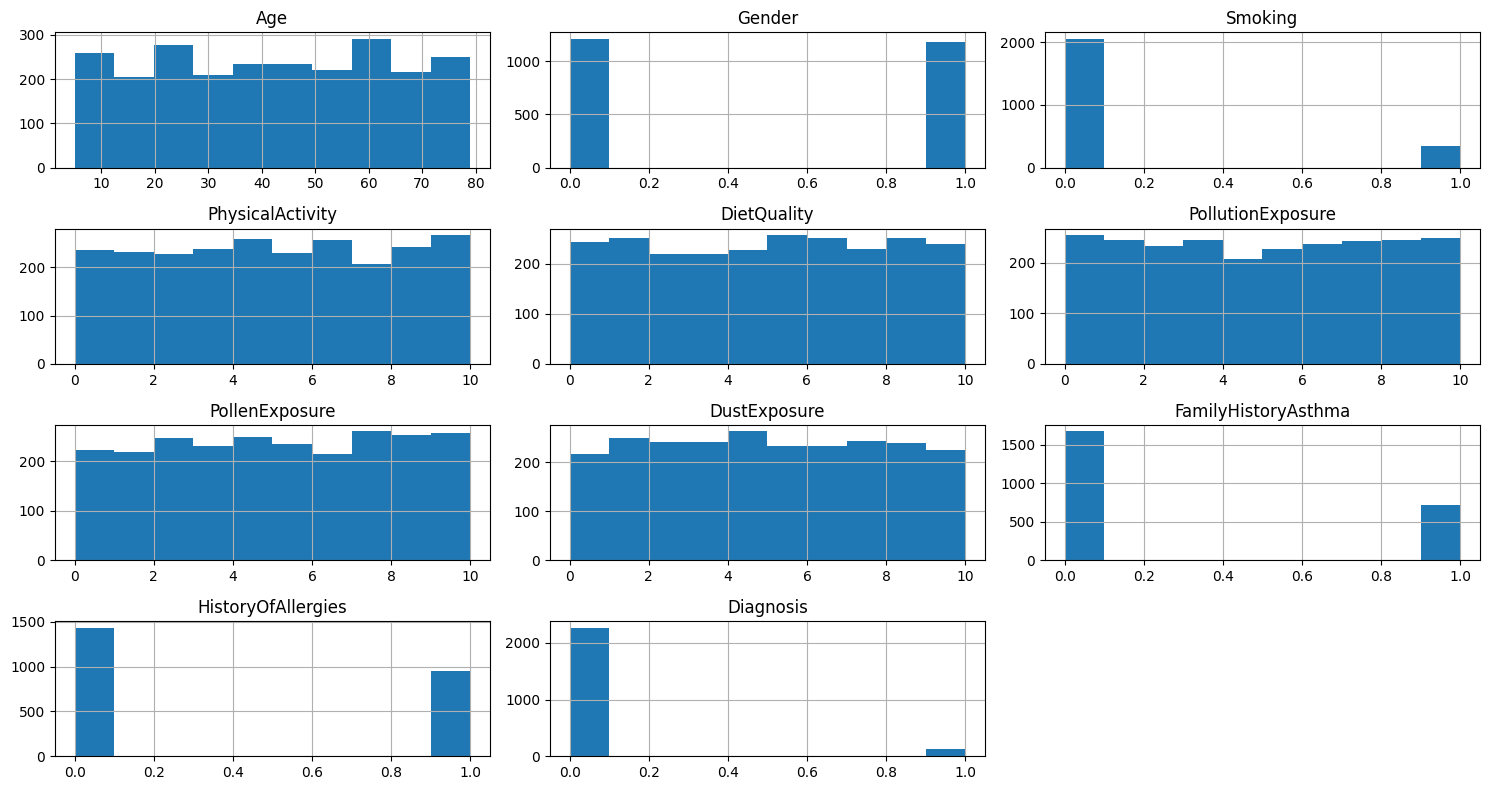

In [123]:
# Visualización de la distribución de los datos
plt.figure(figsize=(10, 6))
df.describe()
df.hist(figsize=(15, 8))
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Grupo de Edad')

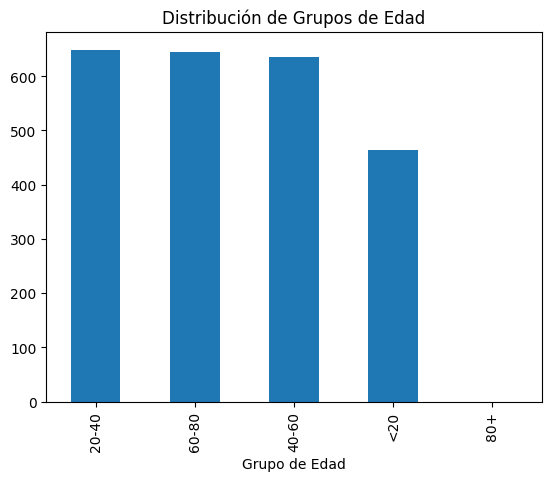

In [124]:
# Agrupación de edades en grupos
max_edad = max(80, df['Age'].max()) + 1
rangos = [0, 20, 40, 60, 80, max_edad]
labels = ['<20', '20‑40', '40‑60', '60‑80', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=rangos, labels=labels, right=False)
df['AgeGroup'].value_counts().plot(kind='bar', title='Distribución de Grupos de Edad')
plt.xlabel('Grupo de Edad')

C:\Users\mauri\AppData\Local\Temp\ipykernel_15884\808225620.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia_edad = df.groupby('AgeGroup')['Diagnosis'].mean()


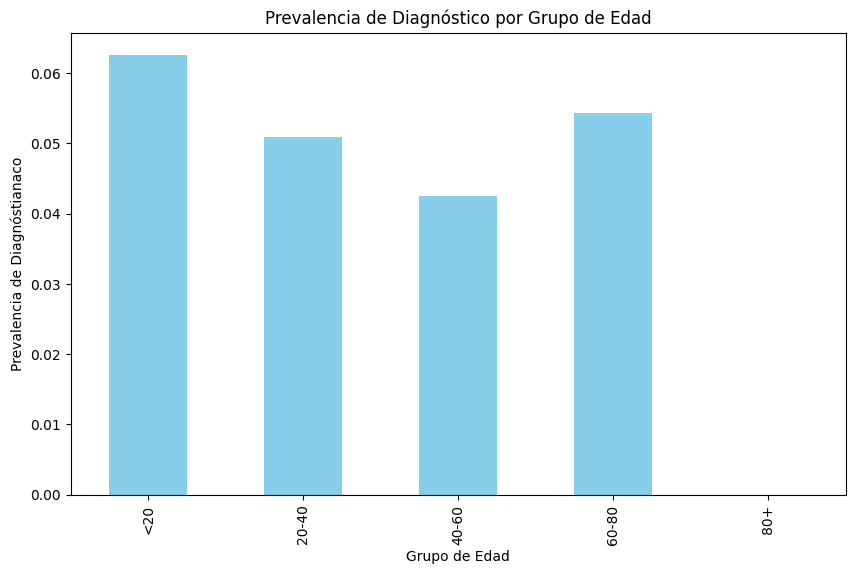

In [125]:
prevalencia_edad = df.groupby('AgeGroup')['Diagnosis'].mean()
plt.figure(figsize=(10, 6))
prevalencia_edad.plot(kind='bar', color='skyblue')
plt.title('Prevalencia de Diagnóstico por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Prevalencia de Diagnóstianaco')
plt.show()